In [191]:
using JLD2, LinearAlgebra,Plots
st=load("try2_wigner.jld2")

Dict{String, Any} with 13 entries:
  "chern_single"  => NaN+NaN*im
  "Flink_single"  => ComplexF64[0.0+0.0im NaN+NaN*im NaN+NaN*im; NaN+NaN*im NaN…
  "energy"        => -8.32896-3.92617e-17im
  "chern"         => -9.69321e-17+5.29651e-17im
  "HFeigenvalue"  => [[-2.3239, -0.155622, -0.0691033, -0.0691033, 0.00820177, …
  "zerocomp"      => [1.74278 2.09262 … 1.42569 1.52613; 2.07248 2.69867 … 1.40…
  "NoHFdensity"   => [9.0 9.0 … 9.0 9.0; 9.0 9.0 … 9.0 9.0; … ; 9.0 9.0 … 9.0 9…
  "HFdensity"     => [1.74278 2.09262 … 1.42569 1.52613; 2.07248 2.69867 … 1.40…
  "densitymatrix" => Vector{Matrix{ComplexF64}}[[[1.17823e-14+2.1414e-29im 3.77…
  "Flink"         => ComplexF64[2.19804e-22-2.09668e-11im -2.21953e-16+4.27564e…
  "output_Ham"    => Matrix{ComplexF64}[[15.749+6.68496e-20im -0.00605535+0.266…
  "TCS"           => NaN+0.0im
  "TC"            => 3.17512+0.0im

In [179]:
scale=1.0
flux=1.0*π
Nq=3
am=4*π/(√3*scale);
β=4*flux/(√3*scale^2)
mass=0.5;

b1=4*π/(√3*am)*[0,1]
b2=4*π/(√3*am)*[√3/2,-1/2]


a1m=am*[1/2,√3/2]
a2m=am*[1,0]


T1=b1/(Nq)
T2=b2/(Nq)



b1T=Int.(round.(inv([T1 T2])*b1))
b2T=Int.(round.(inv([T1 T2])*b2))



allowedq=Vector{Int64}[]
for ja in 0:Nq-1,jb in 0:Nq-1
    push!(allowedq,[ja,jb])
end




wave=Vector{Int64}[]
cutoff=18
cutoffstandard=4.01*scale
for ja in -cutoff:cutoff, jb in -cutoff:cutoff
    gtest=ja*b1+jb*b2;
    if (gtest[1]^2+gtest[2]^2)<cutoffstandard^2
        push!(wave,ja*b1T+jb*b2T)
    end
end
dimension=length(wave)



61

In [180]:
final_eigenvalue=[zeros(Float64,dimension) for _ in 1:Nq^2]
final_eigvector=[zeros(ComplexF64,dimension,dimension) for _ in 1:Nq^2]
for ja in 1:Nq^2
  final_eigenvalue[ja]=real(eigen(st["output_Ham"][ja]).values)
  final_eigvector[ja]=(eigen(st["output_Ham"][ja]).vectors)
end

In [181]:
C3matrix=[-1/2 -√3/2;√3/2 -1/2]
max_diff=0
index1=1
index2=1
for ja in 1:dimension
    k1=wave[ja]
    C3k1=Int.(round.(inv([T1 T2])*(C3matrix*[T1 T2]*k1),digits=5))
    pos=findfirst(item->item==C3k1,wave)
    if abs(abs(final_eigvector[1][ja,1])-abs(final_eigvector[1][pos,1]))>max_diff
        max_diff=abs(abs(final_eigvector[1][ja,1])-abs(final_eigvector[1][pos,1]))
        index1=ja
        index2=pos
    end
end

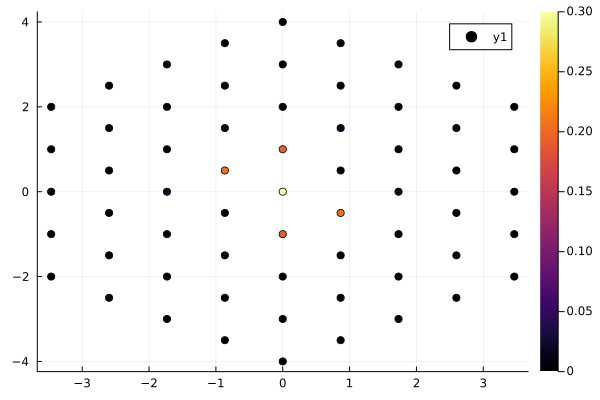

In [190]:
xpoint=[]
ypoint=[]
zpoint=[]
for ja in 1:length(wave)
  vec=[T1 T2]*wave[ja]
  push!(xpoint,vec[1])
  push!(ypoint,vec[2])
  push!(zpoint,real(final_eigvector[1][ja,1]))
end
scatter(xpoint,ypoint,zcolor=zpoint,clim=(0,0.3))

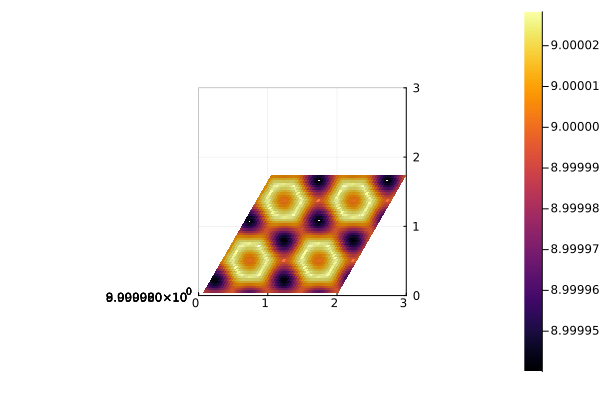

In [183]:
a1m=[1/2,√3/2]
a2m=[1,0]
xgrid=zeros(Float64,50,50)
ygrid=zeros(Float64,50,50)    

for ja in 1:50, jb in 1:50
    rvec=ja/25*a1m+jb/25*a2m
 xgrid[ja,jb]=rvec[1]
 ygrid[ja,jb]=rvec[2]
  
end
plot(xgrid,ygrid,real.(st["HFdensity"]),st=:surf,axis_ratio=:equal,camera=[0,90])
xlims!(0,3)
ylims!(0,3)